In [30]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss, log_loss, roc_auc_score
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
import matplotlib.pyplot as plt

import xgboost as xgb
import joblib


In [31]:
shots = pd.read_csv("../data/shots_clean.csv")
shots.head()

,match_id,shot_x,shot_y,distance,angle,goal,body_part,play_type,under_pressure,keeper_x,keeper_y,nearest_defender,defender_density,defenders_between
0,9880,101.0,21.3,26.658770,0.215408,0,Right Foot,Open Play,False,117.4,37.4,2.690725,2.0,1.0
1,9880,103.9,28.4,19.843639,0.328588,0,Right Foot,Open Play,False,117.3,37.4,1.824829,3.0,0.0
2,9880,112.5,26.0,15.882380,0.248710,0,Left Foot,Open Play,False,117.1,34.0,5.508176,0.0,0.0
3,9880,113.2,46.0,9.068627,0.687568,1,Right Foot,Open Play,False,117.6,42.8,4.313931,1.0,3.0
4,9880,92.8,32.9,28.111386,0.273979,0,Right Foot,Open Play,False,118.6,38.5,2.267157,2.0,0.0


In [32]:
num_cols = [
    "shot_x", "shot_y",
    "distance", "angle",
    "nearest_defender", "defender_density", "defenders_between",
    "keeper_x", "keeper_y"
]

for col in num_cols:
    shots[col] = pd.to_numeric(shots[col], errors="coerce")


In [33]:
shots = shots.fillna({
    "nearest_defender": shots["nearest_defender"].median(),
    "defender_density": 0,
    "defenders_between": 0,
    "keeper_x": shots["keeper_x"].median(),
    "keeper_y": shots["keeper_y"].median(),
    "distance": shots["distance"].median(),
    "angle": shots["angle"].median()
})


Confirm no NaNs

In [34]:
shots.isna().sum()

match_id             0
shot_x               0
shot_y               0
distance             0
angle                0
goal                 0
body_part            0
play_type            0
under_pressure       0
keeper_x             0
keeper_y             0
nearest_defender     0
defender_density     0
defenders_between    0
dtype: int64

Define Features and Target

In [35]:
num_features = num_cols

cat_features = [
    "body_part",
    "play_type",
    "under_pressure"
]

X = shots[num_features + cat_features]
y = shots["goal"]


Train/Test Split

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Preprocessing Pipeline

In [37]:
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
        ("num", "passthrough", num_features)
    ]
)

Logistic Regression Model

In [38]:
log_reg = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=500))
])

Train

In [39]:
log_reg.fit(X_train, y_train)

C:\Users\bcarr\.conda\envs\football-xg\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Predict

In [40]:
y_pred_lr = log_reg.predict_proba(X_test)[:, 1]


Metrics

In [41]:
print("Logistic Regression Performance:")
print("  Brier Score:", brier_score_loss(y_test, y_pred_lr))
print("  Log Loss:", log_loss(y_test, y_pred_lr))
print("  AUC:", roc_auc_score(y_test, y_pred_lr))

Logistic Regression Performance:
  Brier Score: 0.07812149218967393
  Log Loss: 0.2727683127382227
  AUC: 0.8124176277268408


Calibration Plot

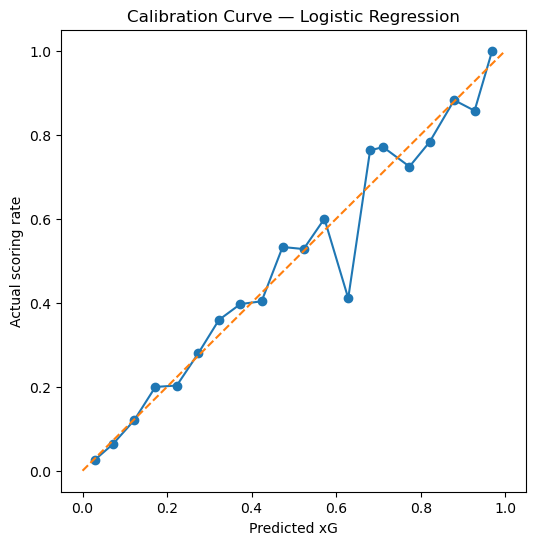

In [42]:
prob_true, prob_pred = calibration_curve(y_test, y_pred_lr, n_bins=20)

plt.figure(figsize=(6,6))
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("Predicted xG")
plt.ylabel("Actual scoring rate")
plt.title("Calibration Curve — Logistic Regression")
plt.show()

XGBoost Model

Encode Data

In [43]:
X_train_enc = preprocess.fit_transform(X_train)
X_test_enc = preprocess.transform(X_test)

Train XGBoost

In [44]:
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric="logloss"
)

xgb_model.fit(X_train_enc, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.9
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [46]:
calibrated_xgb = CalibratedClassifierCV(
    estimator=xgb_model,
    method="isotonic",   # best for non-linear models
    cv=5                 # 5-fold calibration
)

calibrated_xgb.fit(X_train_enc, y_train)

,estimator,"XGBClassifier...ree=None, ...)"
,method,'isotonic'
,cv,5
,n_jobs,None
,ensemble,'auto'
,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None


Evaluate

In [47]:
y_pred_xgb = xgb_model.predict_proba(X_test_enc)[:, 1]

print("XGBoost Performance:")
print("  Brier Score:", brier_score_loss(y_test, y_pred_xgb))
print("  Log Loss:", log_loss(y_test, y_pred_xgb))
print("  AUC:", roc_auc_score(y_test, y_pred_xgb))

XGBoost Performance:
  Brier Score: 0.07577637797689583
  Log Loss: 0.26571769328468015
  AUC: 0.8215389871000345


Calibrated Evaluate

In [50]:
y_pred_cal = calibrated_xgb.predict_proba(X_test_enc)[:, 1]

print("Calibrated XGBoost Performance:")
print("  Brier Score:", brier_score_loss(y_test, y_pred_cal))
print("  Log Loss:", log_loss(y_test, y_pred_cal))
print("  AUC:", roc_auc_score(y_test, y_pred_cal))

Calibrated XGBoost Performance:
  Brier Score: 0.07578634895510891
  Log Loss: 0.2655302252818634
  AUC: 0.822262234345033


Feature Importance

<Figure size 1000x600 with 0 Axes>

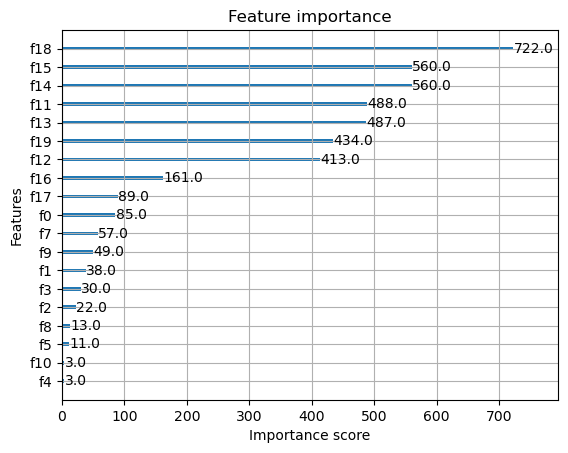

In [51]:
plt.figure(figsize=(10,6))
xgb.plot_importance(xgb_model, max_num_features=20)
plt.show()

Save Models

In [52]:
joblib.dump(log_reg, "../models/xg_logistic.pkl")
joblib.dump(preprocess, "../models/preprocessor.pkl")
joblib.dump(xgb_model, "../models/xgboost.pkl")

['../models/xgboost.pkl']

Example

In [53]:
def predict_xg(features: dict, model_path="../models/xgboost.pkl", preproc_path="../models/preprocessor.pkl"):
    model = joblib.load(model_path)
    preproc = joblib.load(preproc_path)

    df = pd.DataFrame([features])
    X = preproc.transform(df)
    return model.predict_proba(X)[0, 1]


In [54]:
predict_xg({
    "shot_x": 102,
    "shot_y": 40,
    "distance": 18,
    "angle": 0.45,
    "nearest_defender": 2.1,
    "defender_density": 1,
    "defenders_between": 0,
    "keeper_x": 118,
    "keeper_y": 40,
    "body_part": "Right Foot",
    "play_type": "Open Play",
    "under_pressure": False
})

np.float32(0.07877945)